### **EJERCICIO 1**

  Cloning https://github.com/MSMRo/signalDraw-isb.git to /tmp/pip-req-build-1496ewoh
  Running command git clone --filter=blob:none --quiet https://github.com/MSMRo/signalDraw-isb.git /tmp/pip-req-build-1496ewoh
  Resolved https://github.com/MSMRo/signalDraw-isb.git to commit ff5c22c821b47b98f0f8c154c163540086ae2b8d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


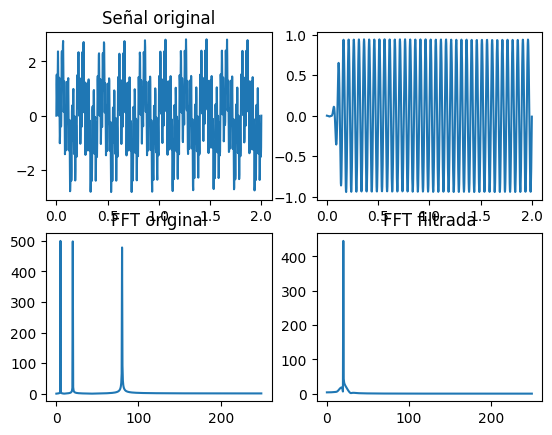

In [ ]:

!pip install git+https://github.com/MSMRo/signalDraw-isb.git

from signaldraw_isb import SignalDraw
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter
from scipy.fft import fft, fftfreq


fs = 500
T = 2
t = np.linspace(0, T, fs*T)


s1 = np.sin(2*np.pi*5*t)
s2 = np.sin(2*np.pi*20*t)
s3 = np.sin(2*np.pi*80*t)

signal = s1 + s2 + s3

N = 101

fir = firwin(
    N,
    [15, 30],
    pass_zero=False,
    fs=fs
)

filtered = lfilter(fir, 1.0, signal)

Nfft = len(signal)

freqs = fftfreq(Nfft, 1/fs)

fft_original = np.abs(fft(signal))
fft_filtered = np.abs(fft(filtered))


plt.subplot(2,2,1)
plt.plot(t, signal)
plt.title("Señal original")

plt.subplot(2,2,2)
plt.plot(t, filtered)

plt.subplot(2,2,3)
plt.plot(freqs[:Nfft//2], fft_original[:Nfft//2])
plt.title("FFT original")

plt.subplot(2,2,4)
plt.plot(freqs[:Nfft//2], fft_filtered[:Nfft//2])
plt.title("FFT filtrada")

plt.show()

### **EJERCICIO 2**

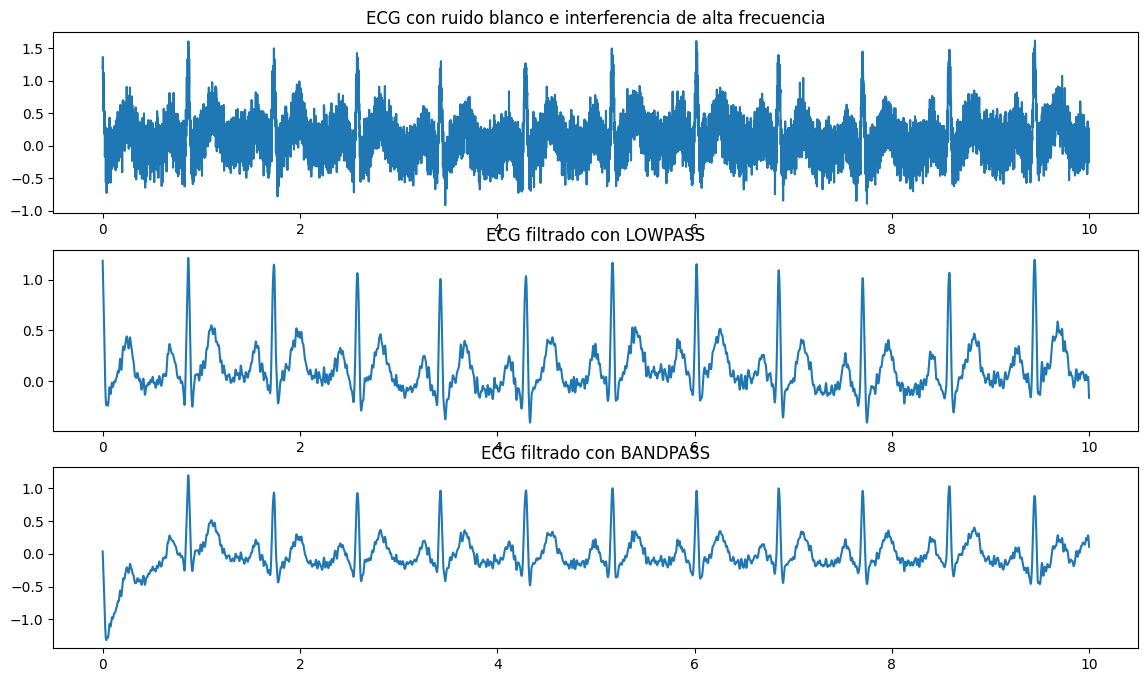

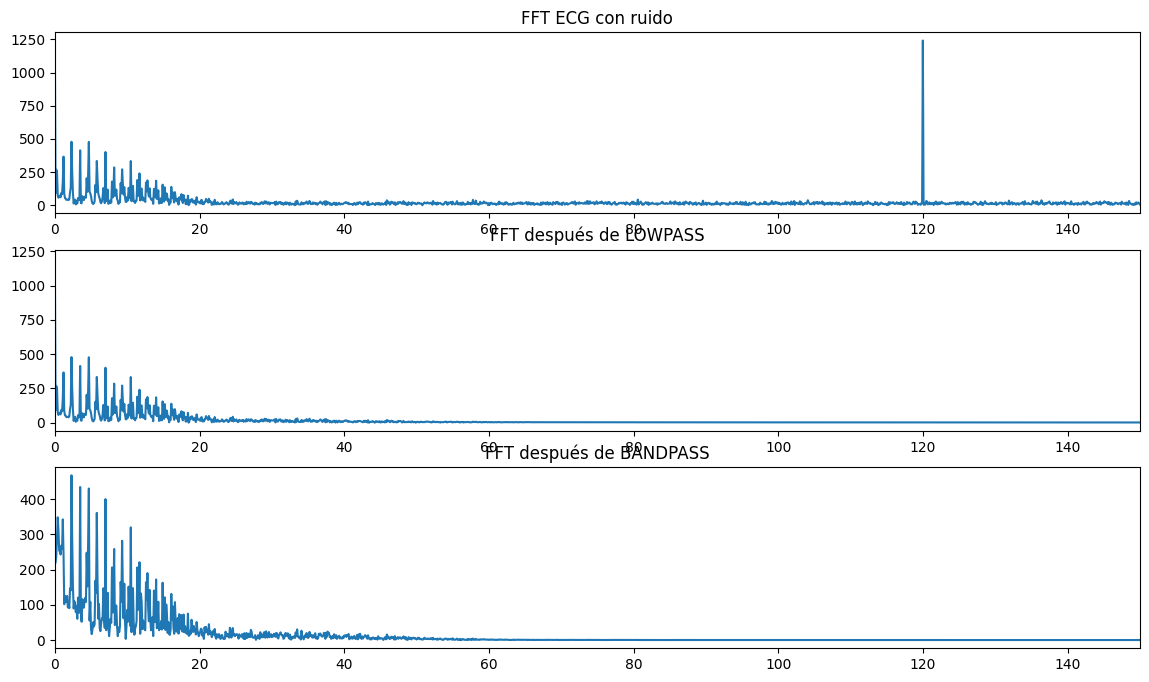

In [ ]:
!pip install neurokit2
import neurokit2 as nk
from scipy.signal import butter, filtfilt

fs = 1000
duration = 10
t = np.arange(0, duration, 1/fs)

ecg = nk.ecg_simulate(
    duration=duration,
    sampling_rate=fs,
    noise=0.01,
    heart_rate=70,
    heart_rate_std=1,
    method="ecgsyn"
)


white_noise = 0.15 * np.random.randn(len(ecg))
high_freq = 0.25 * np.sin(2*np.pi*120*t)

noisy = ecg + white_noise + high_freq

N = 4
fc = 45

b_low, a_low = butter(N, fc, btype='low', fs=fs)
filtered_low = filtfilt(b_low, a_low, noisy)

f1 = 0.5
f2 = 45

b_band, a_band = butter(N, [f1, f2], btype='bandpass', fs=fs)
filtered_band = filtfilt(b_band, a_band, noisy)

Nfft = len(noisy)
freqs = fftfreq(Nfft, 1/fs)

fft_noisy = np.abs(fft(noisy))

fft_low = np.abs(fft(filtered_low))

fft_band = np.abs(fft(filtered_band))


plt.figure(figsize=(14,8))

plt.subplot(3,1,1)
plt.plot(t, noisy)
plt.title("ECG con ruido blanco e interferencia de alta frecuencia")

plt.subplot(3,1,2)
plt.plot(t, filtered_low)
plt.title("ECG filtrado con LOWPASS")

plt.subplot(3,1,3)
plt.plot(t, filtered_band)
plt.title("ECG filtrado con BANDPASS")

plt.show()

plt.figure(figsize=(14,8))

plt.subplot(3,1,1)
plt.plot(freqs[:Nfft//2], fft_noisy[:Nfft//2])
plt.title("FFT ECG con ruido")
plt.xlim(0, 150)

plt.subplot(3,1,2)
plt.plot(freqs[:Nfft//2], fft_low[:Nfft//2])
plt.title("FFT después de LOWPASS")
plt.xlim(0, 150)

plt.subplot(3,1,3)
plt.plot(freqs[:Nfft//2], fft_band[:Nfft//2])
plt.title("FFT después de BANDPASS")
plt.xlim(0, 150)

plt.show()

### **EJERCICIO 3**

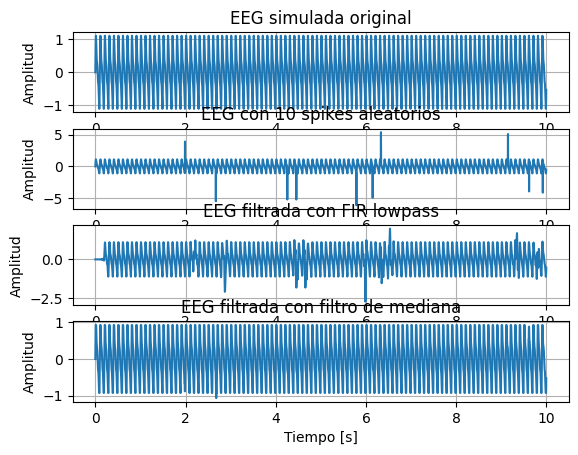

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import firwin, lfilter, medfilt

fs=250
t_duracion= 10
t = np.arange(0, t_duracion, 1/fs)

a=0.8*np.sin(2*np.pi*10*t)
b= 0.4*np.sin(2*np.pi*20*t)
c= 0.2*np.sin(2*np.pi*30*t)
eeg = a+b+c

np.random.seed(42)

eeg_spikes = eeg.copy()
spike_positions = np.random.choice(len(eeg_spikes), 10, replace=False)

for pos in spike_positions:
    eeg_spikes[pos] += np.random.choice([5, -5])

#pasabajos
N = 101
fc = 40

fir = firwin(N, fc, pass_zero=True, fs=fs)
eeg_lowpass = lfilter(fir, 1.0, eeg_spikes)

#mediana
eeg_median = medfilt(eeg_spikes, kernel_size=5)

plt.subplot(4,1,1)
plt.plot(t, eeg)
plt.title("EEG simulada original")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(4,1,2)
plt.plot(t, eeg_spikes)
plt.title("EEG con 10 spikes aleatorios")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(4,1,3)
plt.plot(t, eeg_lowpass)
plt.title("EEG filtrada con FIR lowpass")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()

plt.subplot(4,1,4)
plt.plot(t, eeg_median)
plt.title("EEG filtrada con filtro de mediana")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid()


### **EJERCICIO 4**

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 13.1 MB/s eta 0:00:00


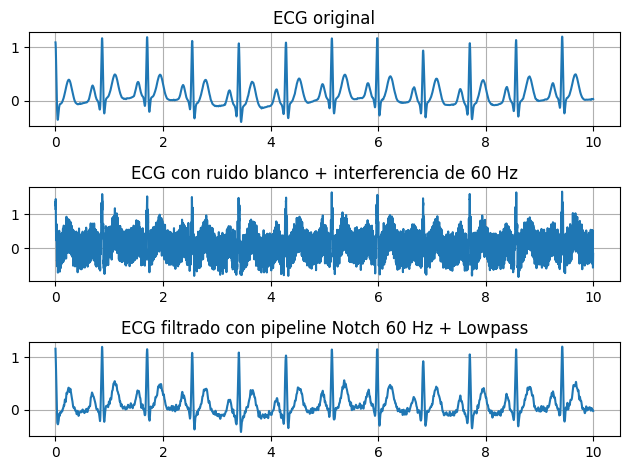

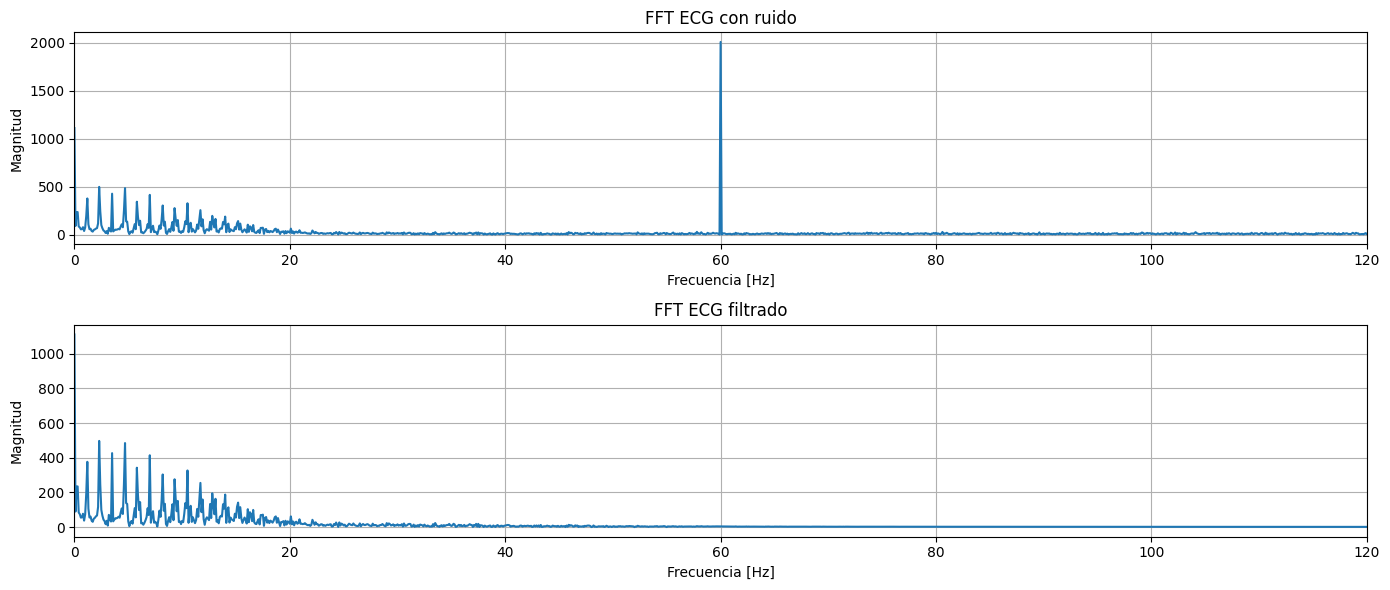

In [6]:
!pip install neurokit2

import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import iirnotch, butter, filtfilt
from scipy.fft import fft, fftfreq

fs = 1000
duration = 10
t = np.arange(0, duration, 1/fs)

ecg = nk.ecg_simulate(
    duration=duration,
    sampling_rate=fs,
    noise=0.01,
    heart_rate=70,
    heart_rate_std=1,
    method="ecgsyn"
)

# Ruido 60 Hz + ruido blanco
noise_60 = 0.4*np.sin(2*np.pi*60*t)
white_noise = 0.1*np.random.randn(len(t))

noisy = ecg + noise_60 + white_noise

# 1) Notch 60 Hz: elimina interferencia eléctrica
b_notch, a_notch = iirnotch(60, 30, fs)
ecg_notch = filtfilt(b_notch, a_notch, noisy)

# 2) Lowpass: elimina ruido de alta frecuencia
b_low, a_low = butter(4, 45, btype="low", fs=fs)
ecg_filtered = filtfilt(b_low, a_low, ecg_notch)

# FFT
Nfft = len(noisy)
freqs = fftfreq(Nfft, 1/fs)

fft_noisy = np.abs(fft(noisy))
fft_filtered = np.abs(fft(ecg_filtered))

# Gráficas temporales

plt.subplot(3,1,1)
plt.plot(t, ecg)
plt.title("ECG original")
plt.grid()

plt.subplot(3,1,2)
plt.plot(t, noisy)
plt.title("ECG con ruido blanco + interferencia de 60 Hz")
plt.grid()

plt.subplot(3,1,3)
plt.plot(t, ecg_filtered)
plt.title("ECG filtrado con pipeline Notch 60 Hz + Lowpass")
plt.grid()

plt.tight_layout()
plt.show()

# Gráficas FFT
plt.figure(figsize=(14,6))

plt.subplot(2,1,1)
plt.plot(freqs[:Nfft//2], fft_noisy[:Nfft//2])
plt.title("FFT ECG con ruido")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 120)
plt.grid()

plt.subplot(2,1,2)
plt.plot(freqs[:Nfft//2], fft_filtered[:Nfft//2])
plt.title("FFT ECG filtrado")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.xlim(0, 120)
plt.grid()

plt.tight_layout()

### **EJERCICIO 5**

Delay respiración estimado: -1100 muestras
Delay acelerómetro estimado: -16 muestras


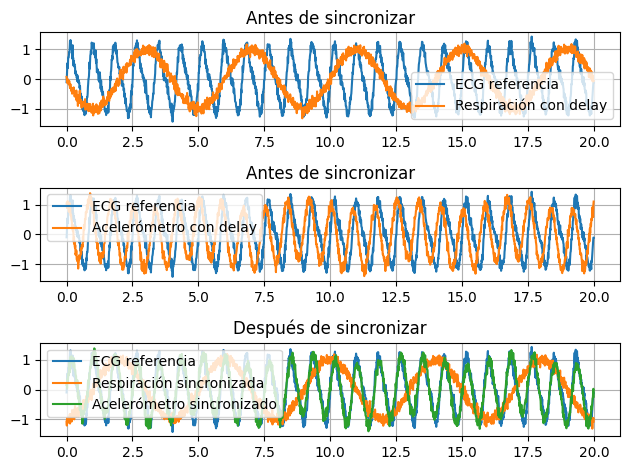

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate

fs = 100
duration = 20
t = np.arange(0, duration, 1/fs)

ecg = np.sin(2*np.pi*1.2*t) + 0.3*np.sin(2*np.pi*2.4*t)
resp = np.sin(2*np.pi*0.25*t)
acc = np.sin(2*np.pi*1.2*t) + 0.2*np.sin(2*np.pi*0.25*t)

# Ruido gaussiano
ecg = ecg + 0.1*np.random.randn(len(t))
resp = resp + 0.1*np.random.randn(len(t))
acc = acc + 0.1*np.random.randn(len(t))

delay_resp = 2 * fs
delay_acc = 4 * fs

resp_delay = np.roll(resp, delay_resp)
acc_delay = np.roll(acc, delay_acc)


def estimar_delay(ref, sig):
    corr = correlate(sig, ref, mode="full")
    lags = np.arange(-len(ref)+1, len(ref))
    delay = lags[np.argmax(corr)]
    return delay

delay_resp_est = estimar_delay(ecg, resp_delay)
delay_acc_est = estimar_delay(ecg, acc_delay)

print("Delay respiración estimado:", delay_resp_est, "muestras")
print("Delay acelerómetro estimado:", delay_acc_est, "muestras")


resp_sync = np.roll(resp_delay, -delay_resp_est)
acc_sync = np.roll(acc_delay, -delay_acc_est)


plt.subplot(3,1,1)
plt.plot(t, ecg, label="ECG referencia")
plt.plot(t, resp_delay, label="Respiración con delay")
plt.title("Antes de sincronizar")
plt.legend()
plt.grid()

plt.subplot(3,1,2)
plt.plot(t, ecg, label="ECG referencia")
plt.plot(t, acc_delay, label="Acelerómetro con delay")
plt.title("Antes de sincronizar")
plt.legend()
plt.grid()

plt.subplot(3,1,3)
plt.plot(t, ecg, label="ECG referencia")
plt.plot(t, resp_sync, label="Respiración sincronizada")
plt.plot(t, acc_sync, label="Acelerómetro sincronizado")
plt.title("Después de sincronizar")
plt.legend()
plt.grid()

plt.tight_layout()

### **EJERCICIO 6**

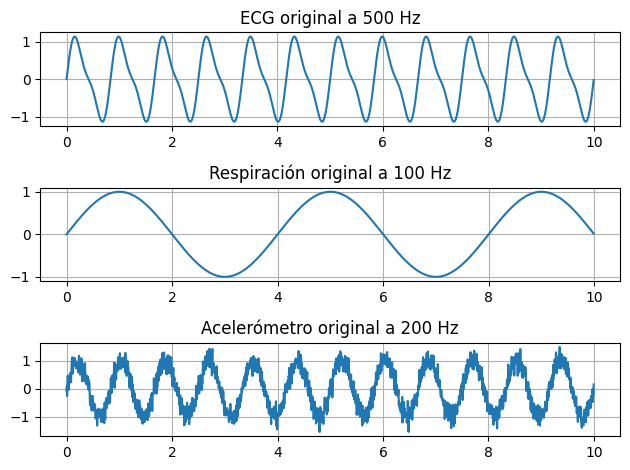

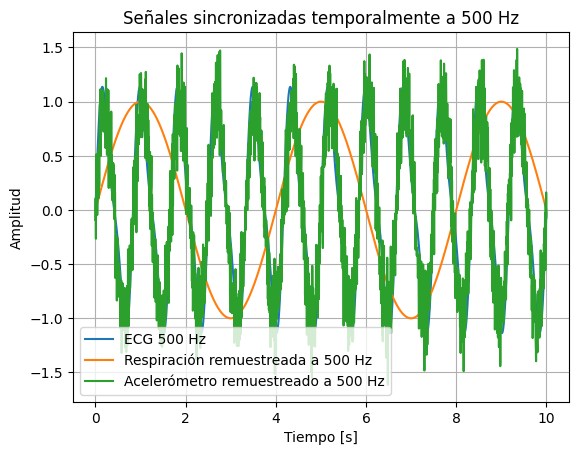

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

fs_ecg = 500
fs_resp = 100
fs_acc = 200

fs_new = 500
duration = 10

t_ecg = np.arange(0, duration, 1/fs_ecg)
t_resp = np.arange(0, duration, 1/fs_resp)
t_acc = np.arange(0, duration, 1/fs_acc)

ecg = np.sin(2*np.pi*1.2*t_ecg) + 0.3*np.sin(2*np.pi*2.4*t_ecg)
resp = np.sin(2*np.pi*0.25*t_resp)
acc = np.sin(2*np.pi*1.2*t_acc) + 0.2*np.random.randn(len(t_acc))

n_new = int(duration * fs_new)

ecg_500 = ecg
resp_500 = resample(resp, n_new)
acc_500 = resample(acc, n_new)

t_500 = np.arange(0, duration, 1/fs_new)


plt.subplot(3,1,1)
plt.plot(t_ecg, ecg)
plt.title("ECG original a 500 Hz")
plt.grid()

plt.subplot(3,1,2)
plt.plot(t_resp, resp)
plt.title("Respiración original a 100 Hz")
plt.grid()

plt.subplot(3,1,3)
plt.plot(t_acc, acc)
plt.title("Acelerómetro original a 200 Hz")
plt.grid()

plt.tight_layout()
plt.show()

plt.plot(t_500, ecg_500, label="ECG 500 Hz")
plt.plot(t_500, resp_500, label="Respiración remuestreada a 500 Hz")
plt.plot(t_500, acc_500, label="Acelerómetro remuestreado a 500 Hz")

plt.title("Señales sincronizadas temporalmente a 500 Hz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()
plt.show()